In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import timeit
import matplotlib.pyplot as plt
import torch.nn as nn
import random
from dreal import *
from matplotlib import cm
import math
import matplotlib.patches as patches


In [2]:

torch.cuda.empty_cache()
torch.manual_seed(42)
random.seed()

device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
numerical_x = torch.Tensor(1000, 2).uniform_(-6, 6).float().to(device)


Using device: cpu


# Given dynamical system:


We consider the following system:
\begin{align*}
\begin{bmatrix}
    \dot{x}_1\\
    \dot{x}_2
\end{bmatrix}=\begin{bmatrix}
    x_2-x_1^3+x_1^2\\
    0
\end{bmatrix}+\begin{bmatrix}
    0\\
    1
\end{bmatrix}u
\end{align*}
And the unsafe set to be:
\begin{align*}
    C_1^c=\{(x_1,x_2):(x_1+2)^2+(x_2+2)^2\leq 0.25\} \Rightarrow h(x)=(x_1+2)^2+(x_2+2)^2-0.25
\end{align*}
Assume the point of stability to be $(0,0)$. Then the lie derivatives can be written as:
\begin{align}
    L_fh(x)&=2(x_1+2)(x_2-x_1^3+x_1^2)\\
    L_gh(x)&=2(x_2+2)
\end{align}
and we will take $\alpha$ to be linear and quadratic.


In [3]:
def f(x):
    if x.dim() == 1:
        x = x.unsqueeze(0)

    val = torch.stack(
        [ x[:,1]-(x[:,0]**3) + (x[:,0]**2),
            torch.zeros_like(x[:, 0])
        ], dim=1
    )
    return val.squeeze(0) if val.shape[0] == 1 else val

def g(x):
    """Vectorized g(x) - handles batched input"""
    if x.dim() == 1:
        x = x.unsqueeze(0)
    
    val = torch.stack([
        torch.zeros_like(x[:, 0]),
        torch.full_like(x[:, 0], 1.0)
    ], dim=1)
    
    return val.squeeze(0) if val.shape[0] == 1 else val

def div_f(x):
    """Vectorized divergence of f - handles batched input: div(f)= damping * (1-x[0]^2)"""
    if x.dim() == 1:
        return torch.tensor(-3*x[:,0]**2+2*x[:,0], device=device)
    else:
        return -3*x[:,0]**2+2*x[:,0]
    

def div_g(x):
    """Vectorized divergence of g"""
    if x.dim() == 1:
        return torch.tensor(0.0, device=device)
    else:
        return torch.zeros(x.shape[0], device=device)
    
def h(x):

    """ h(x) is basically the boundary for safe and unsafe regions which is a circle: x_1^2+x_2^2-0.25"""
    if x.dim() == 1:
        x = x.unsqueeze(0)
    val = (x[:,0]+2)**2 + (x[:,1]+2)**2 - 0.25
    return val.squeeze(0) if val.shape[0] == 1 else val

# add more dataset into numerical_x from unsafe set
unsafe_samples = torch.Tensor(2000, 2).uniform_(-6, 6).float().to(device)
unsafe_samples = unsafe_samples[h(unsafe_samples) <= 0]
print(unsafe_samples.shape)
numerical_x = torch.cat([numerical_x, unsafe_samples], dim=0)


torch.Size([14, 2])


In [4]:

class polynomial_net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class polynomial_net_bias_Zero(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(polynomial_net_bias_Zero, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
                layer.bias.requires_grad = False
                

    def forward(self, x):
        return self.net(x)
                

class numerator_polynomial_net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(numerator_polynomial_net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

class GammaFunctionNet(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GammaFunctionNet, self).__init__()
        self.linear_layer = nn.Linear(input_dim, output_dim)
        nn.init.constant_(self.linear_layer.weight, 0)
        nn.init.constant_(self.linear_layer.bias, 0)
        self.linear_layer.weight.requires_grad = False

    def forward(self, x):
        if x.dim() == 1:
            return abs(self.linear_layer.bias)
        return abs(self.linear_layer.bias.expand(x.shape[0], -1))

In [5]:

def gradient_batch(func, x):
    """Compute gradients for a batch of inputs efficiently"""
    x = x.clone().detach().requires_grad_(True)
    output = func(x).sum()
    grad = torch.autograd.grad(outputs=output, inputs=x, create_graph=True)[0]
    return grad

def gradient_batch_special_b(func, x):
    """Compute gradients of ||f(x)||^2 for a batch efficiently"""
    x = x.clone().detach().requires_grad_(True)
    output = func(x)
    output_norm_squared = (output ** 2).sum(dim=1).sum()
    grad = torch.autograd.grad(outputs=output_norm_squared, inputs=x, create_graph=True)[0]
    return grad

# ==================== FULLY VECTORIZED CONTROL DENSITY ====================

def control_density_risk_vectorized(x, f_fun, g_fun, a_fun, b_fun, c_fun):
    """FULLY VECTORIZED - processes entire batch at once"""
    # x = x[h(x)>0]
    batch_size = x.shape[0]
    
    # Compute all values in batch
    divergence_at_f = div_f(x)  # [batch_size]
    divergence_at_g = div_g(x)  # [batch_size]
    
    # Compute gradients for entire batch
    grad_at_a = gradient_batch(a_fun, x)  # [batch_size, 2]
    grad_at_c = gradient_batch(c_fun, x)  # [batch_size, 2]
    grad_at_b = gradient_batch_special_b(b_fun, x)  # [batch_size, 2]
    
    # Compute function values
    a_vals = a_fun(x).squeeze()  # [batch_size]
    c_vals = c_fun(x).squeeze()  # [batch_size]
    f_vals = f(x)  # [batch_size, 2]
    g_vals = g(x)  # [batch_size, 2]
    
    # Vectorized computation of term1
    term1 = (a_vals * divergence_at_f + 
             divergence_at_g * c_vals + 
             (grad_at_a * f_vals).sum(dim=1) + 
             (grad_at_c * g_vals).sum(dim=1))
    
    # Vectorized computation of term2
    scaled_x = 2 * x + grad_at_b  # [batch_size, 2]
    combined = f_vals * a_vals.unsqueeze(1) + g_vals * c_vals.unsqueeze(1)  # [batch_size, 2]
    term2 = (scaled_x * combined).sum(dim=1)
    
    return term1 - term2

def control_density_loss(x, f_fun, g_fun, a_fun, b_fun, c_fun, gamma_fun):
    """Optimized loss computation"""
    divergence = control_density_risk_vectorized(x, f_fun, g_fun, a_fun, b_fun, c_fun)
    gamma_vals = gamma_fun(x).squeeze()
    
    loss = F.relu(gamma_vals - divergence).mean()
    a_loss = F.relu( - a_fun(x).squeeze()).mean()
    gamma_loss = F.relu(-gamma_vals).mean()
    # x_unsafe = x[h(x)<=0]
    # a_loss2 = (a_fun(x_unsafe)**2).mean()
    
    return loss + a_loss + gamma_loss 

def control_safety_loss(x,a_fun,c_fun,h_fun):
    # x = x[h(x)>0]
    lie_derivative_g = 2*(x[:,1]+2)
    lie_derivative_f = 2 * (x[:,0]+2) * (x[:,1]-x[:,0]**3 + x[:,0]**2) 
    first_constraint = c_fun(x).squeeze() * lie_derivative_g
    second_constraint = a_fun(x).squeeze() * lie_derivative_f + a_fun(x).squeeze() * (h_fun(x)**5)
    total_constraint = first_constraint + second_constraint
    safety_loss = F.relu(-total_constraint).mean()
    return safety_loss


In [6]:

def checkSMTconstraints(vars, a_learnt, divergence_learnt,safety_learnt, ball_lb, ball_ub, config, epsilon=0):
    """Check the SMT constraints for the given variables and learnt parameters"""
    ball = Expression(0)
    
    for i in range(len(vars)):
        ball += vars[i]**2
    ball_in_bound = logical_and(ball >= ball_lb, ball <= ball_ub)
    
    a_condition = a_learnt >= 0
    divergence_condition = divergence_learnt > 0
    stability_condition = logical_and(
        logical_imply(ball_in_bound, divergence_condition),
        logical_imply(ball_in_bound, a_condition)
    )
 
    return CheckSatisfiability(logical_not(stability_condition), config)

def AddCounterexamples(x, CE, N, device):
    """Adds counterexamples to the sample set efficiently"""
    nearby = []
    for i in range(CE.size()):
        lb = CE[i].lb()
        ub = CE[i].ub()
        nearby_ = np.random.uniform(lb, ub, N)
        nearby.append(nearby_)
    
    # Vectorized counterexample addition
    new_points = np.column_stack(nearby)
    new_points_tensor = torch.tensor(new_points, dtype=torch.float32, device=device)
    x = torch.cat((x, new_points_tensor), dim=0)
    x = torch.unique(x, dim=0)
    
    return x, new_points_tensor

# ==================== SYMBOLIC NN CLASSES ====================

class SymbolicNN:
    """Convert neural networks to symbolic expressions for dReal"""
    def __init__(self, net):
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        z = vars
        for i in range(len(self.weights) - 1):
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            z = [tanh(zi) for zi in z]
        z = self._linear_symbolic(z, self.weights[-1], self.biases[-1])
        return z

    def _linear_symbolic(self, x, weight, bias):
        out = []
        for i in range(weight.shape[0]):
            expr = bias[i]
            for j in range(weight.shape[1]):
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out

class activSymbolicNN:
    """Convert neural networks with sigmoid to symbolic expressions"""
    def __init__(self, net):
        self.weights = []
        self.biases = []
        self.extract_params(net)

    def extract_params(self, net):
        for layer in net.net:
            if isinstance(layer, nn.Linear):
                self.weights.append(layer.weight.detach().cpu().numpy())
                if layer.bias is not None:
                    self.biases.append(layer.bias.detach().cpu().numpy())

    def forward_symbolic(self, vars):
        z = vars
        for i in range(len(self.weights)):
            z = self._linear_symbolic(z, self.weights[i], self.biases[i])
            z = [(1/(1 + exp(-zi))) for zi in z]
        return z

    def _linear_symbolic(self, x, weight, bias):
        out = []
        for i in range(weight.shape[0]):
            expr = bias[i]
            for j in range(weight.shape[1]):
                expr += weight[i,j] * x[j]
            out.append(expr)
        return out

def candidate_constraint_learnt(vars, a_fun, b_fun, c_fun):
    """Construct candidate constraints for the learnt functions"""
    a_sym = activSymbolicNN(a_fun).forward_symbolic(vars)[0]
    b_sym = SymbolicNN(b_fun).forward_symbolic(vars)
    c_sym = SymbolicNN(c_fun).forward_symbolic(vars)[0]
    
    b_sym = sum([bi**2 for bi in b_sym])
    
    # Symbolic dynamics for inverted pendulum
    f_val = [
        vars[1]-vars[0]**3+vars[0]**2,
        0
    ]
    g_val = [
        0.0 * vars[0],
        1.0 
    ]
    
    f_div = - 3 * (vars[0]**2) + 2 * vars[0]
    g_div = 0
    
    grad_a = [a_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_c = [c_sym.Differentiate(vars[i]) for i in range(len(vars))]
    grad_b = [b_sym.Differentiate(vars[i]) for i in range(len(vars))]
    
    constraint1 = (a_sym * f_div + g_div * c_sym + 
                   sum([grad_a[i] * f_val[i] for i in range(len(f_val))]) + 
                   sum([grad_c[i] * g_val[i] for i in range(len(g_val))]))
    
    scaled_vars = [2 * var_i for var_i in vars]
    constraint2 = [scaled_vars[i] + grad_b[i] for i in range(len(vars))]
    constraint2 = sum([constraint2[i] * (f_val[i] * a_sym + g_val[i] * c_sym) 
                      for i in range(len(f_val))])
    
    constraint = constraint1 - constraint2

    safety_constraint = a_sym * (2 * (vars[0] + 2) * (vars[1] - vars[0]**3 + vars[0]**2) + ( (vars[0] + 2)**2 + (vars[1] + 2)**2 - 0.25 )**5 ) + c_sym * (2 * (vars[1] + 2))
    return a_sym, constraint, safety_constraint


In [7]:

def train_density(x, epochs=2000, lr=1e-2, ball_lb=0.5, ball_ub=2, check_interval=10):
    """Train density function with SMT-based counterexample refinement"""
    loss_total_density = []
    

    a_net = numerator_polynomial_net(2,4, 1).to(device)
    c_net = polynomial_net(2, 16, 1).to(device)
    b_net = polynomial_net_bias_Zero(2,4, 2).to(device)
    gamma_net = GammaFunctionNet(2, 1).to(device)
    
    optimizer = torch.optim.Adam(
        list(a_net.parameters()) + list(c_net.parameters()) + 
        list(b_net.parameters()) + list(gamma_net.parameters()), 
        lr=lr
    )
    
    # Configure dReal SMT solver
    config = Config()
    config.use_polytope_in_forall = True
    config.use_local_optimization = True
    config.precision = 1e-5
    
    valid = False
    print("Training density function with SMT verification")
    print(f"Initial dataset size: {x.shape[0]}")
    # discounting_factor = 0.99999
    while not valid:
        for epoch in range(epochs):
            optimizer.zero_grad()
            # loss = control_density_loss(x, f, g, a_net, b_net, c_net, gamma_net) 
            
            safety_loss = control_safety_loss(x, a_net, c_net, h)
            loss =  control_density_loss(x, f, g, a_net, b_net, c_net, gamma_net) + 1000 * safety_loss
            # discounting_factor *= 0.99999
            loss_total_density.append(loss.item())
            loss.backward()
            optimizer.step()
            
            if loss.item() < 0.005:
                print(f"  [Epoch {epoch}] Loss reached zero!")
                valid = True
                break
            
            if epoch % 50 == 0:
                print(f"Epoch {epoch}/{epochs}, Loss: {loss.item():.4f}, Dataset size: {x.shape[0]}")
                print(f"  Safety Loss: {safety_loss.item():.6f}")
            
            # # Check for counterexamples periodically
            # if epoch % check_interval == 0 and epoch > 0:
            #     print(f"  [Epoch {epoch}] Checking SMT constraints...")
            #     vars = [Variable("x1"), Variable("x2")]
                
            #     try:
            #         a_learnt, divergence_learnt, safety_learnt = candidate_constraint_learnt(vars, a_net, b_net, c_net)
            #         CE = checkSMTconstraints(vars, a_learnt, divergence_learnt,safety_learnt, ball_lb, ball_ub, config)
                    
            #         if CE:
            #             print(f" Counterexample found! Adding 100 new points...")
            #             x_before = x.shape[0]
            #             x, n_pt_tensor = AddCounterexamples(x, CE, 100, device)
            #             x_after = x.shape[0]
            #             print(f"  Dataset size: {x_before} → {x_after} (+{x_after - x_before} unique)")
            #         else:
            #             valid = True
            #             print(" No counterexample found - constraints satisfied!")
            #             break
            #     except Exception as e:
            #         print(f"   SMT check failed: {e}")
            #         continue
        
    
    print(f"\nTraining completed!")
    print(f"Final Loss: {loss.item():.4f}")
    test_point = torch.tensor([[0, 0]], dtype=torch.float32, device=device)
    print(f"The learned margin is {gamma_net(test_point).item():.6f}")
    print(f"Final dataset size: {x.shape[0]}")
    
    return loss_total_density, a_net, b_net, c_net, gamma_net


In [8]:

def plot_results(risks, labels):
    """Plot risk curves"""
    plt.figure(figsize=(10, 6))
    for risk, label in zip(risks, labels):
        plt.plot(risk, label=label)
    plt.xlabel("Iteration")
    plt.ylabel("Risk")
    plt.title("Risk Over Iterations")
    plt.legend()
    plt.grid()
    plt.show()


def plot_density_contours(a_nn, b_nn, c_nn,density_threshold, device, plot_flow=True):
    """Plot density contours with optional flow field"""
    x1 = torch.linspace(-6, 6, 500)
    x2 = torch.linspace(-6, 6, 500)
    X, Y = np.meshgrid(x1.cpu().numpy(), x2.cpu().numpy())
    
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), 
                               dtype=torch.float32).to(device)
    
    with torch.no_grad():
        rho_set = a_nn(grid_points) / (torch.exp(
            torch.sum(grid_points**2, dim=1, keepdim=True) + 
            torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)
        ))
        rho_set = rho_set.squeeze().cpu().numpy().reshape(X.shape)
    
    fig, ax = plt.subplots(figsize=(8, 6))

    
    # ax.contour(X,Y,rho_set,levels=0,colors='black', linewidths=2,linestyles='solid', label='Density')

    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')
    unsafe_region = (X+2)**2 + (Y+2)**2 <= 0.25
    ax.contourf(X, Y, unsafe_region, levels=[0.5, 1], colors='black', alpha=0.99)
    
    if plot_flow:
        x1_flow = np.linspace(-6, 6, 100)
        x2_flow = np.linspace(-6, 6, 100)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), 
                                   dtype=torch.float32).to(device)
        
        with torch.no_grad():
            u_values = (c_nn(flow_points) / (a_nn(flow_points) + 1e-9)).squeeze()
        
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                flow = f_val + g_val * u
                # flow = f_val
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        magnitude = np.sqrt(DX**2 + DY**2) + 1e-9
        DX = DX / magnitude
        DY = DY / magnitude
        # magnitudex = np.sqrt(DX**2)
        # magnitudey = np.sqrt(DY**2 )
        # DX_norm = DX / magnitudex
        # DY_norm = DY / magnitudey
        
        ax.streamplot(X_flow, Y_flow, DX, DY, color='Gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    circle = plt.Circle((0, 0), 6, color='r', fill=False, 
                        linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title('Density Function Contours with Flow Field')
    ax.legend()
    ax.grid(True)
    plt.show()
    
    return fig, ax


In [17]:
def plot_density_contours1(a_nn, b_nn, c_nn, density_threshold, device, plot_flow=True):
    """Plot density contours with optional flow field"""
    x1 = torch.linspace(-6, 6, 500)
    x2 = torch.linspace(-6, 6, 500)
    X, Y = np.meshgrid(x1.cpu().numpy(), x2.cpu().numpy())
    
    grid_points = torch.tensor(np.column_stack([X.ravel(), Y.ravel()]), 
                               dtype=torch.float32).to(device)
    
    with torch.no_grad():
        rho_set = (1e+5)*a_nn(grid_points) / (torch.exp(
            torch.sum(grid_points**2, dim=1, keepdim=True) + 
            torch.sum((b_nn(grid_points))**2, dim=1, keepdim=True)
        ))
        rho_set = rho_set.squeeze().cpu().numpy().reshape(X.shape)
    
    fig, ax = plt.subplots(figsize=(8, 6))

    filled_contours = ax.contourf(X, Y, rho_set, levels=10, alpha=0.3, cmap=cm.coolwarm)
    plt.colorbar(filled_contours, label='Density Value')
    unsafe_region = (X+2)**2 + (Y+2)**2 <= 0.25
    ax.contourf(X, Y, unsafe_region, levels=[0.5, 1], colors='black', alpha=0.99)
    
    if plot_flow:
        x1_flow = np.linspace(-6, 6, 80)
        x2_flow = np.linspace(-6, 6, 80)
        X_flow, Y_flow = np.meshgrid(x1_flow, x2_flow)
        flow_points = torch.tensor(np.column_stack([X_flow.ravel(), Y_flow.ravel()]), 
                                   dtype=torch.float32).to(device)
        
        with torch.no_grad():
            u_values = (c_nn(flow_points) / (a_nn(flow_points) + 1e-9)).squeeze()
        
        DX = np.zeros_like(X_flow)
        DY = np.zeros_like(Y_flow)
        
        for i in range(len(x1_flow)):
            for j in range(len(x2_flow)):
                idx = i * len(x1_flow) + j
                x = torch.tensor([X_flow[i, j], Y_flow[i, j]], device=device)
                f_val = f(x)
                g_val = g(x)
                u = u_values[idx]
                
                flow = f_val + g_val * u
                DX[i, j] = flow[0].cpu().numpy()
                DY[i, j] = flow[1].cpu().numpy()
        
        # Mask the velocity field inside the unsafe region
        unsafe_mask = (X_flow +2)**2 + (Y_flow +2)**2 <= 0.25
        DX[unsafe_mask] = np.nan
        DY[unsafe_mask] = np.nan
        
        # Normalize only valid (non-NaN) values
        magnitude = np.sqrt(DX**2 + DY**2)
        valid_mask = ~np.isnan(magnitude) & (magnitude > 1e-9)
        DX[valid_mask] = DX[valid_mask] / magnitude[valid_mask]
        DY[valid_mask] = DY[valid_mask] / magnitude[valid_mask]
        
        ax.streamplot(X_flow, Y_flow, DX, DY, color='Gray', linewidth=0.5,
                     density=1.0, arrowstyle='-|>', arrowsize=1.5)
    
    circle = plt.Circle((0, 0), 6, color='r', fill=False, 
                        linewidth=1.5, label='Valid Region')
    ax.add_artist(circle)
    
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_title('Density Function Contours with Flow Field')
    ax.legend()
    ax.grid(True)
    plt.show()
    
    return fig, ax

In [10]:
print("=" * 60)
print("Van der Pol Oscillator")
print("=" * 60)

# Train the density function
loss_density, a_ret, b_ret, c_ret, gamma_net = train_density(
    numerical_x, epochs=4000, lr=1e-5, ball_lb=0.5, ball_ub=6, check_interval=1500
)


Van der Pol Oscillator
Training density function with SMT verification
Initial dataset size: 1014
Epoch 0/4000, Loss: 566.8795, Dataset size: 1014
  Safety Loss: 0.566076
Epoch 50/4000, Loss: 565.9943, Dataset size: 1014
  Safety Loss: 0.565145
Epoch 100/4000, Loss: 565.1078, Dataset size: 1014
  Safety Loss: 0.564212
Epoch 150/4000, Loss: 564.2191, Dataset size: 1014
  Safety Loss: 0.563276
Epoch 200/4000, Loss: 563.3296, Dataset size: 1014
  Safety Loss: 0.562338
Epoch 250/4000, Loss: 562.4395, Dataset size: 1014
  Safety Loss: 0.561399
Epoch 300/4000, Loss: 561.5477, Dataset size: 1014
  Safety Loss: 0.560457
Epoch 350/4000, Loss: 560.6541, Dataset size: 1014
  Safety Loss: 0.559513
Epoch 400/4000, Loss: 559.7596, Dataset size: 1014
  Safety Loss: 0.558568
Epoch 450/4000, Loss: 558.8890, Dataset size: 1014
  Safety Loss: 0.557647
Epoch 500/4000, Loss: 558.0816, Dataset size: 1014
  Safety Loss: 0.556796
Epoch 550/4000, Loss: 557.2999, Dataset size: 1014
  Safety Loss: 0.555975
Epoch


Plotting loss curve...


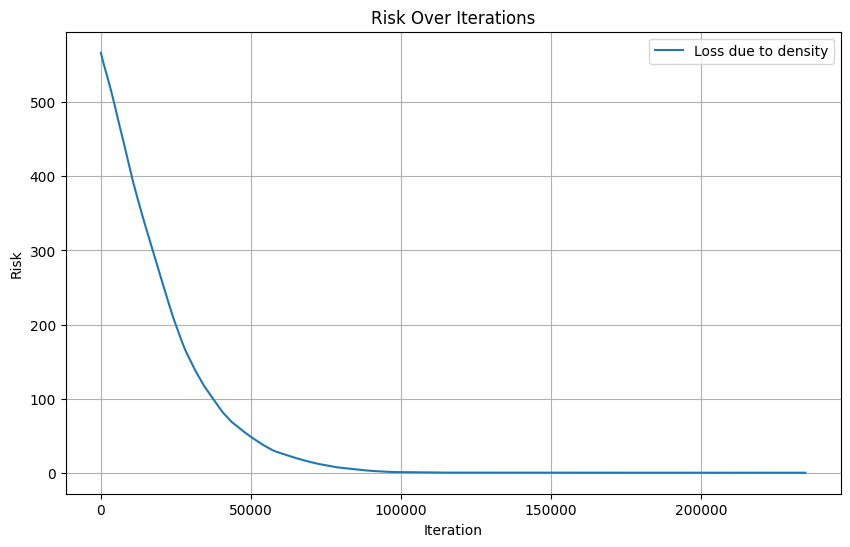

In [11]:

# Plot loss curve
print("\nPlotting loss curve...")
risks = [loss_density]
plot_results(risks, labels=['Loss due to density'])



Generating density visualization...


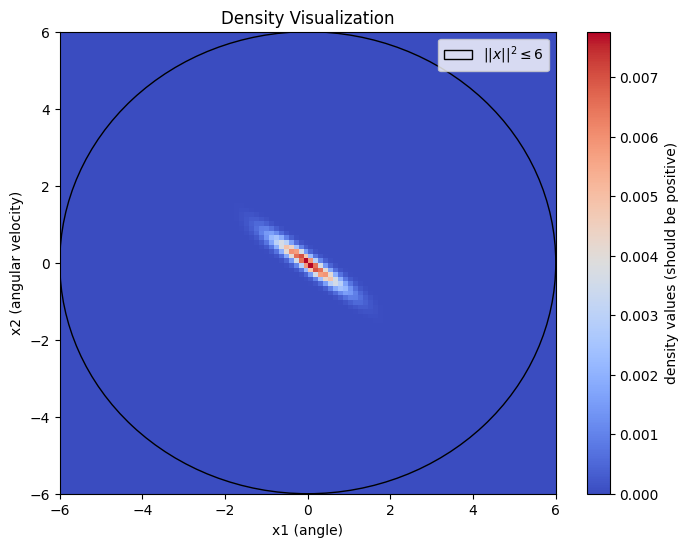

In [12]:

# Visualize density
print("\nGenerating density visualization...")
grid_size = 100
x1 = torch.linspace(-6, 6, grid_size)
x2 = torch.linspace(-6, 6, grid_size)
x1_grid, x2_grid = torch.meshgrid(x1, x2, indexing='ij')
grid_points = torch.stack([x1_grid.ravel(), x2_grid.ravel()], dim=1).to(device)

with torch.no_grad():
    rho_set = a_ret(grid_points) / (torch.exp(
        torch.sum(grid_points**2, dim=1, keepdim=True) + 
        torch.sum((b_ret(grid_points))**2, dim=1, keepdim=True)
    ))

violations_set = rho_set.detach().cpu().numpy().reshape(grid_size, grid_size)

plt.figure(figsize=(8, 6))
plt.imshow(violations_set, extent=[-6, 6, -6, 6], origin='lower',
            cmap='coolwarm', aspect='auto')
plt.colorbar(label="density values (should be positive)")
plt.xlabel("x1 (angle)")
plt.ylabel("x2 (angular velocity)")
plt.title("Density Visualization")
circle = patches.Circle((0, 0), 6, color='black', fill=False, 
                        linewidth=1, label="$||x||^2 \\leq 6$")
plt.gca().add_patch(circle)
plt.legend(loc='upper right')
plt.grid(False)
plt.show()



Generating divergence visualization...
torch.Size([10000])


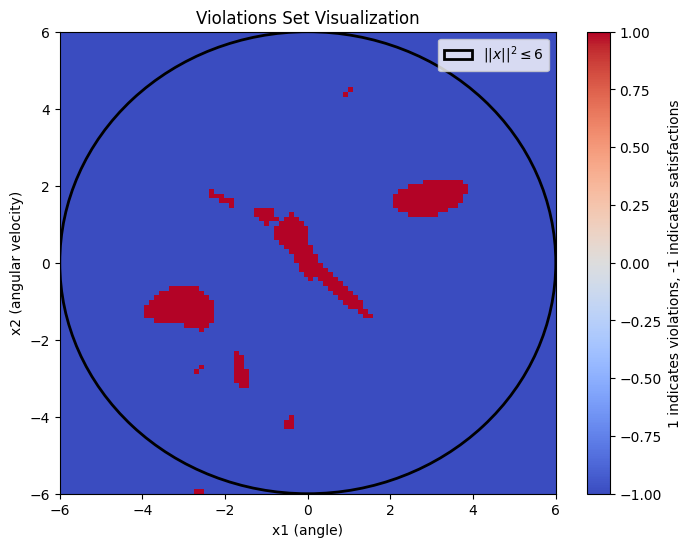

In [13]:

# Visualize divergence/violations
print("\nGenerating divergence visualization...")
# Note: control_density_risk_vectorized needs gradients, so we don't use no_grad here
divergence_set = control_density_risk_vectorized(grid_points, f, g, a_ret, b_ret, c_ret)
print(divergence_set.shape)
violations_set = torch.where(divergence_set <= 0, 1, -1)
violations_set = violations_set.detach().cpu().numpy().reshape(grid_size, grid_size)

plt.figure(figsize=(8, 6))
plt.imshow(violations_set, extent=[-6, 6, -6, 6], origin='lower',
            cmap='coolwarm', aspect='auto')
plt.colorbar(label="1 indicates violations, -1 indicates satisfactions")
plt.xlabel("x1 (angle)")
plt.ylabel("x2 (angular velocity)")
plt.title("Violations Set Visualization")
circle = patches.Circle((0, 0), 6, color='black', fill=False, 
                        linewidth=2, label="$||x||^2 \\leq 6$")
plt.gca().add_patch(circle)
plt.legend(loc='upper right')
plt.grid(False)
plt.show()

torch.Size([10000, 2])
torch.Size([10000])


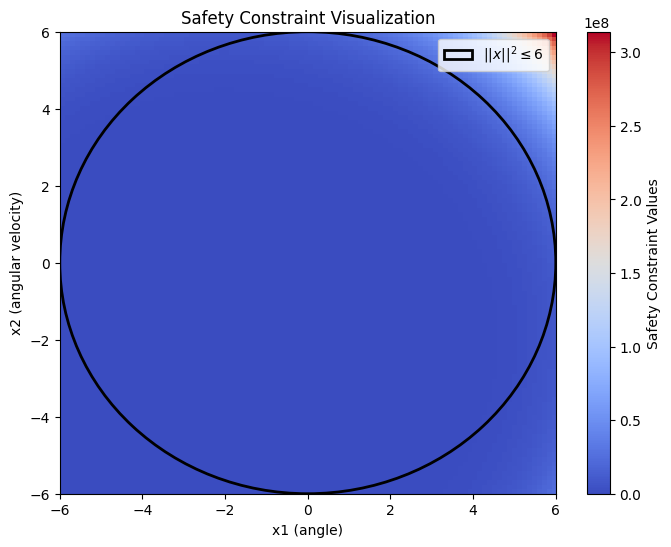

In [14]:
# a(L_fh + \alpha(h))+ c(L_gh) >=0
grid_size = 100
x1 = torch.linspace(-6, 6, grid_size)
x2 = torch.linspace(-6, 6, grid_size)
x1_grid, x2_grid = torch.meshgrid(x1, x2, indexing='ij')
grid_points = torch.stack([x1_grid.ravel(), x2_grid.ravel()], dim=1).to(device)

def plot_safety_helper(x,a_fun,c_fun,h_fun):
    print(x.shape)
    # x = x[h(x)>0]
    lie_derivative_g = 2 * (x[:,0]+2)+ 2*(x[:,1]+0)
    lie_derivative_f = 2 * (x[:,0]+2) * (-torch.pi * torch.sin(np.pi * x[:, 0]) * torch.cos(np.pi * x[:, 1])) + 2 * (x[:,1]+0) * (torch.pi * torch.cos(np.pi * x[:, 0]) * torch.sin(np.pi * x[:, 1]))
    first_constraint = c_fun(x).squeeze() * lie_derivative_g
    second_constraint = a_fun(x).squeeze() * lie_derivative_f + a_fun(x).squeeze() * (h_fun(x)**5)
    total_constraint = first_constraint + second_constraint
    print(total_constraint.shape)
    return total_constraint

safety_vals = plot_safety_helper(grid_points, a_ret, c_ret, h)

safety_vals = safety_vals.detach().cpu().numpy().reshape(grid_size, grid_size)
plt.figure(figsize=(8, 6))
plt.imshow(safety_vals, extent=[-6, 6, -6, 6], origin='lower',
            cmap='coolwarm', aspect='auto')
plt.colorbar(label="Safety Constraint Values")
plt.xlabel("x1 (angle)")
plt.ylabel("x2 (angular velocity)")
plt.title("Safety Constraint Visualization")
circle = patches.Circle((0, 0), 6, color='black', fill=False, 
                        linewidth=2, label="$||x||^2 \\leq 6$")
plt.gca().add_patch(circle)
plt.legend(loc='upper right')
plt.grid(False)
plt.show()



Plotting density contours with flow field...


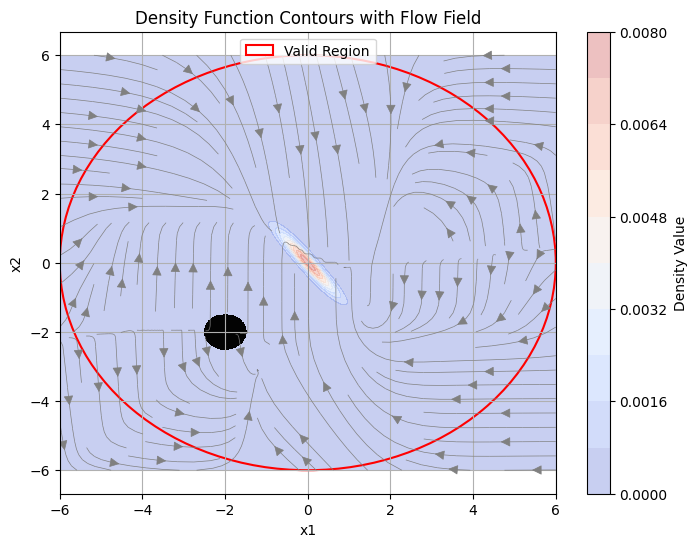


EXPERIMENT COMPLETED!


In [15]:


# Plot density contours with flow field
print("\nPlotting density contours with flow field...")
plot_density_contours(a_ret, b_ret, c_ret,5e-8, device, plot_flow=True)

print("\n" + "=" * 60)
print("EXPERIMENT COMPLETED!")
print("=" * 60)


Plotting density contours with flow field...


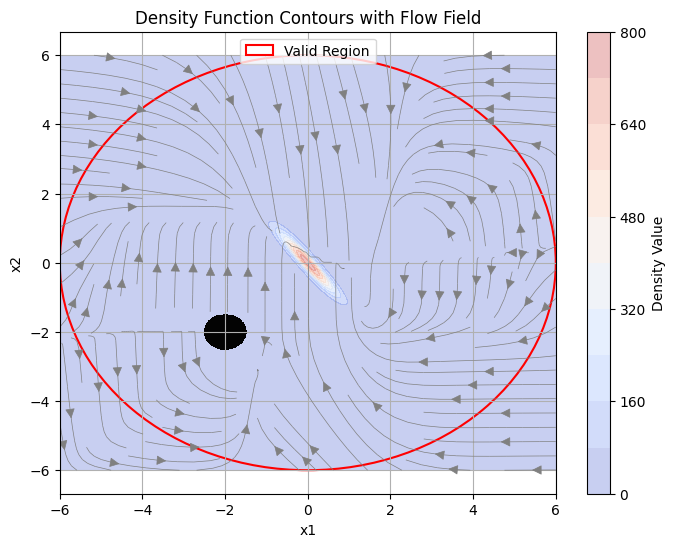


EXPERIMENT COMPLETED!


In [18]:


# Plot density contours with flow field
print("\nPlotting density contours with flow field...")
plot_density_contours1(a_ret, b_ret, c_ret,5e-8, device, plot_flow=True)

print("\n" + "=" * 60)
print("EXPERIMENT COMPLETED!")
print("=" * 60)